In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv('q1_heart_disease.csv')

print("=" * 50)
print(f"Dataset Shape: {df.shape}")
print("=" * 50)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Value Counts:")
print(df.isnull().sum())

print("\nFirst Five Rows:")
df.head()

Dataset Shape: (800, 12)

Data Types:
age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object

Missing Value Counts:
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

First Five Rows:


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


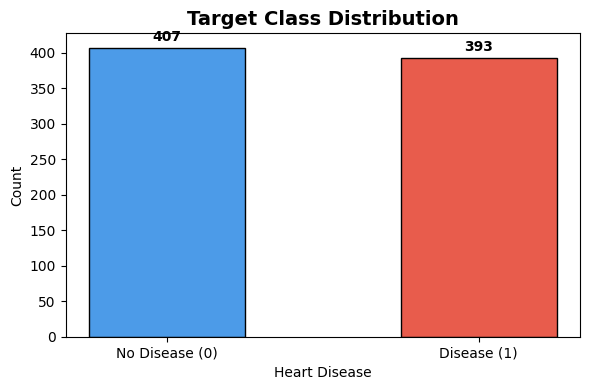

In [32]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['heart_disease'].value_counts()
bars = ax.bar(['No Disease (0)', 'Disease (1)'], counts.values,
              color=['#4C9BE8', '#E85C4C'], edgecolor='black', width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', va='bottom', fontweight='bold')
ax.set_title('Target Class Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
ax.set_xlabel('Heart Disease')
plt.tight_layout()
plt.savefig('plot1_target_distribution.png', dpi=120)
plt.show()

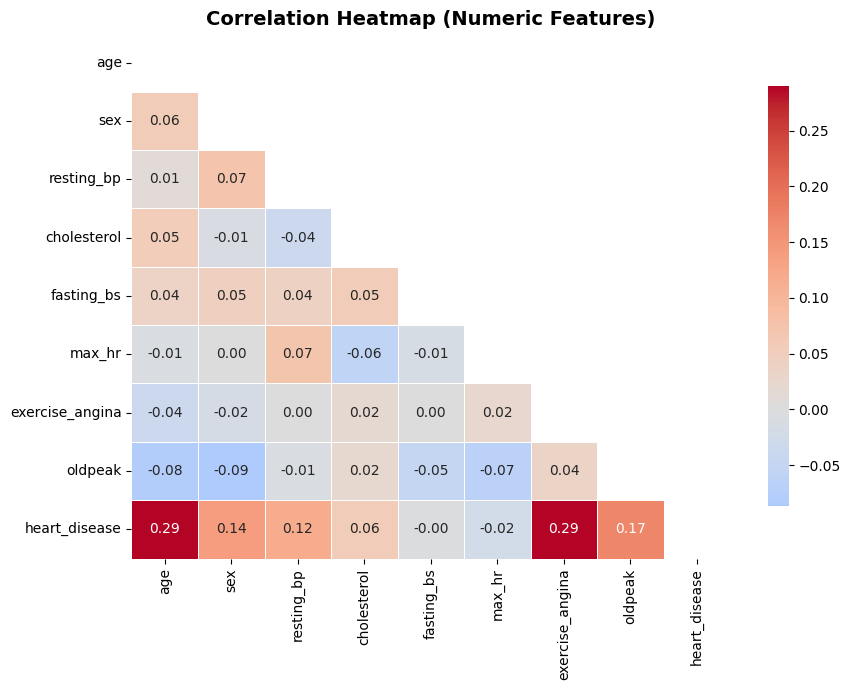

In [33]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9,7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap (Numeric Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot2_correlation_heatmap.png', dpi=120)
plt.show()

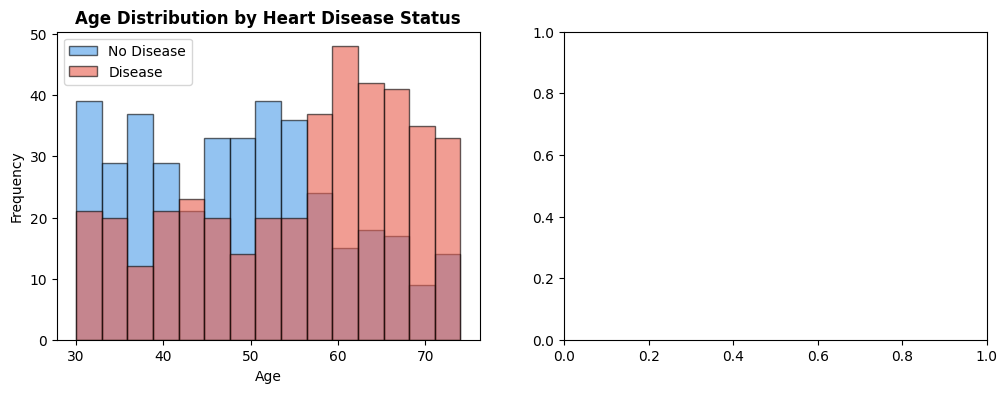

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# KDE / histogram
for label, color in zip([0, 1], ['#4C9BE8', '#E85C4C']):
    axes[0].hist(df[df['heart_disease'] == label]['age'],
                 bins=15, alpha=0.6, color=color,
                 label='No Disease' if label == 0 else 'Disease',
                 edgecolor='black')
axes[0].set_title('Age Distribution by Heart Disease Status', fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')
axes[0].legend()

In [35]:
df_plot = df[['max_hr', 'heart_disease']].copy()
df_plot['Status'] = df_plot['heart_disease'].map({0: 'No Disease', 1: 'Disease'})
sns.boxplot(data=df_plot, x='Status', y='max_hr',
            palette={'No Disease': '#4C9BE8', 'Disease': '#E85C4C'}, ax=axes[1])
axes[1].set_title('Max Heart Rate by Heart Disease Status', fontweight='bold')
axes[1].set_xlabel('Status')
axes[1].set_ylabel('Max Heart Rate')

plt.tight_layout()
plt.savefig('plot3_age_maxhr.png', dpi=120)
plt.show()

<Figure size 640x480 with 0 Axes>

In [36]:
from sklearn.impute import SimpleImputer

categorical_cols = ['chest_pain_type', 'resting_ecg', 'st_slope']
numerical_cols   = ['age', 'sex', 'resting_bp', 'cholesterol',
                    'fasting_bs', 'max_hr', 'exercise_angina', 'oldpeak']
target_col = 'heart_disease'

X = df.drop(columns=[target_col])
y = df[target_col]

In [37]:
imputer = SimpleImputer(strategy='median')
X[numerical_cols] = imputer.fit_transform(X[numerical_cols])

print("Missing values after imputation:")
print(X.isnull().sum())

Missing values after imputation:
age                0
sex                0
chest_pain_type    0
resting_bp         0
cholesterol        0
fasting_bs         0
resting_ecg        0
max_hr             0
exercise_angina    0
oldpeak            0
st_slope           0
dtype: int64


In [38]:
X = pd.get_dummies(X, columns=categorical_cols,drop_first=False)
print(f"Shape after one-hot encoding:{X.shape}")
print("New columns:", [c for c in X.columns if c not in numerical_cols])

Shape after one-hot encoding:(800, 18)
New columns: ['chest_pain_type_asymptomatic', 'chest_pain_type_atypical_angina', 'chest_pain_type_non_anginal', 'chest_pain_type_typical_angina', 'resting_ecg_left_ventricular_hypertrophy', 'resting_ecg_normal', 'resting_ecg_st_t_wave_abnormality', 'st_slope_down', 'st_slope_flat', 'st_slope_up']


In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Training set : {X_train.shape} | Test set: {X_test.shape}")
print(f"Train target distribution:\n{y_train.value_counts()}")
print(f"Test  target distribution:\n{y_test.value_counts()}")

Training set : (640, 18) | Test set: (160, 18)
Train target distribution:
heart_disease
1    326
0    314
Name: count, dtype: int64
Test  target distribution:
heart_disease
1    81
0    79
Name: count, dtype: int64


In [40]:
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols]  = scaler.transform(X_test[numerical_cols])

print("Numerical features scaled. Example (first row of X_train):")
print(X_train[numerical_cols].iloc[0].round(3))

Numerical features scaled. Example (first row of X_train):
age                0.852
sex                0.716
resting_bp         0.722
cholesterol        1.051
fasting_bs        -0.553
max_hr             0.595
exercise_angina   -0.650
oldpeak           -0.150
Name: 737, dtype: float64


In [41]:
models = {
    'Decision Tree'     : DecisionTreeClassifier(random_state=42),
    'Random Forest'     : RandomForestClassifier(random_state=42),
    'Gradient Boosting' : GradientBoostingClassifier(random_state=42),
}


X_train.fillna(0, inplace=True)

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"✔  {name} trained successfully.")

✔  Decision Tree trained successfully.
✔  Random Forest trained successfully.
✔  Gradient Boosting trained successfully.



  Decision Tree
              precision    recall  f1-score   support

  No Disease       0.72      0.71      0.71        79
     Disease       0.72      0.73      0.72        81

    accuracy                           0.72       160
   macro avg       0.72      0.72      0.72       160
weighted avg       0.72      0.72      0.72       160


  Random Forest
              precision    recall  f1-score   support

  No Disease       0.80      0.76      0.78        79
     Disease       0.78      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160


  Gradient Boosting
              precision    recall  f1-score   support

  No Disease       0.77      0.77      0.77        79
     Disease       0.78      0.78      0.78        81

    accuracy                           0.78       160
   macro avg       0.77      0.77      0.77       160
weighted avg       

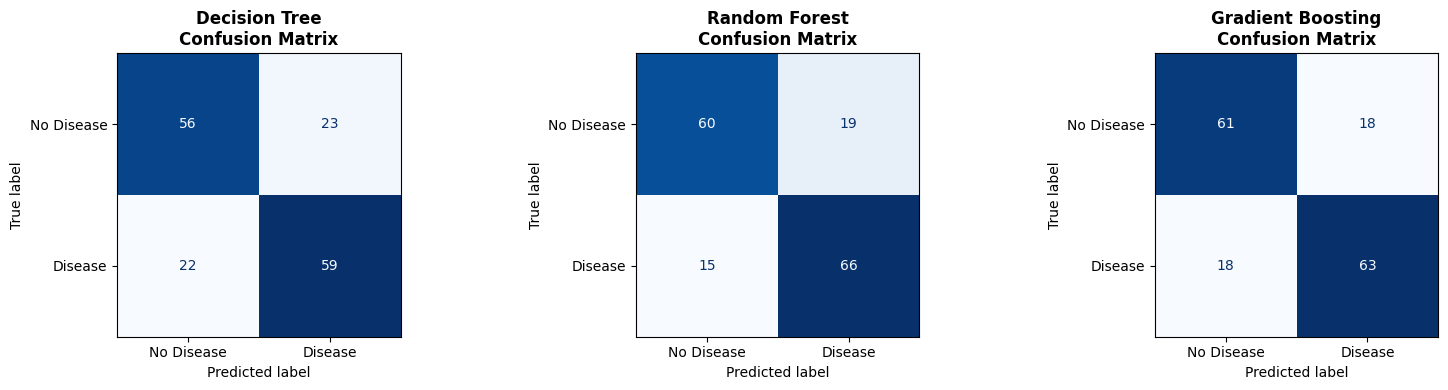

In [42]:
results = {}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

X_test.fillna(0, inplace=True)

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Disease', 'Disease'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nConfusion Matrix', fontweight='bold')
    report = classification_report(y_test, y_pred, output_dict=True)
    results[name] = {
        'precision' : report['weighted avg']['precision'],
        'recall'    : report['weighted avg']['recall'],
        'f1'        : report['weighted avg']['f1-score'],
    }

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred,
                                 target_names=['No Disease', 'Disease']))

plt.tight_layout()
plt.savefig('plot4_confusion_matrices.png', dpi=120)
plt.show()

In [43]:
summary = pd.DataFrame(results).T.round(4)
print("\nWeighted-average metrics across all models:")
print(summary.to_string())


Weighted-average metrics across all models:
                   precision  recall      f1
Decision Tree         0.7187  0.7188  0.7187
Random Forest         0.7881  0.7875  0.7873
Gradient Boosting     0.7750  0.7750  0.7750


In [44]:
param_grid = {
    'n_estimators' : [100, 200],
    'max_depth'    : [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.2],
}

gb_base = GradientBoostingClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator  = gb_base,
    param_grid = param_grid,
    scoring    = 'f1_weighted',
    cv         = 5,
    n_jobs     = -1,
    verbose    = 1,
)

grid_search.fit(X_train, y_train)

print(f"\nBest Parameters Found: {grid_search.best_params_}")
print(f"Best CV F1-Score      : {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best Parameters Found: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Best CV F1-Score      : 0.8297


In [45]:
from sklearn.metrics import f1_score, precision_score, recall_score

best_gb = grid_search.best_estimator_
y_pred_tuned   = best_gb.predict(X_test)
y_pred_untuned = models['Gradient Boosting'].predict(X_test)

comparison = pd.DataFrame({
    'Metric'   : ['Precision', 'Recall', 'F1-Score'],
    'Untuned'  : [
        precision_score(y_test, y_pred_untuned, average='weighted'),
        recall_score(y_test, y_pred_untuned, average='weighted'),
        f1_score(y_test, y_pred_untuned, average='weighted'),
    ],
    'Tuned (GridSearchCV)': [
        precision_score(y_test, y_pred_tuned, average='weighted'),
        recall_score(y_test, y_pred_tuned, average='weighted'),
        f1_score(y_test, y_pred_tuned, average='weighted'),
    ],
}).round(4)

print("\nGradient Boosting — Untuned vs Tuned:")
print(comparison.to_string(index=False))

print("\nDetailed classification report (Tuned model):")
print(classification_report(y_test, y_pred_tuned,
                             target_names=['No Disease', 'Disease']))


Gradient Boosting — Untuned vs Tuned:
   Metric  Untuned  Tuned (GridSearchCV)
Precision    0.775                0.7876
   Recall    0.775                0.7875
 F1-Score    0.775                0.7874

Detailed classification report (Tuned model):
              precision    recall  f1-score   support

  No Disease       0.79      0.77      0.78        79
     Disease       0.78      0.80      0.79        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160



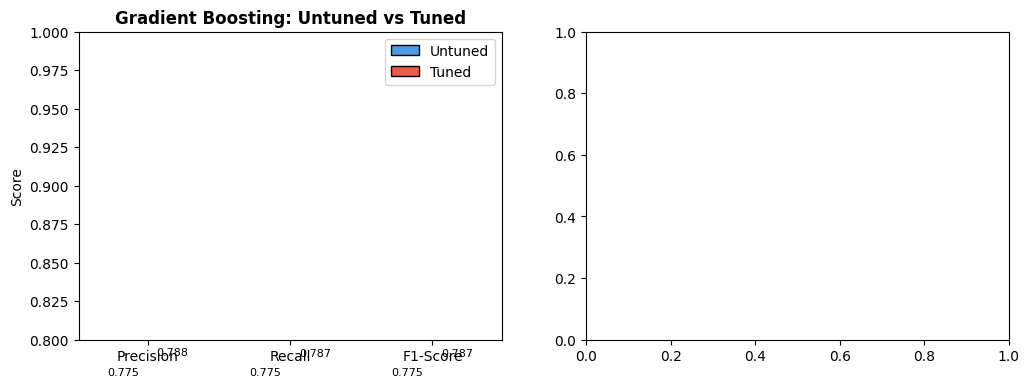

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
metrics = ['Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.35

untuned_vals = [
    precision_score(y_test, y_pred_untuned, average='weighted'),
    recall_score(y_test, y_pred_untuned, average='weighted'),
    f1_score(y_test, y_pred_untuned, average='weighted'),
]
tuned_vals = [
    precision_score(y_test, y_pred_tuned, average='weighted'),
    recall_score(y_test, y_pred_tuned, average='weighted'),
    f1_score(y_test, y_pred_tuned, average='weighted'),
]

axes[0].bar(x - width/2, untuned_vals, width, label='Untuned',
            color='#4C9BE8', edgecolor='black')
axes[0].bar(x + width/2, tuned_vals, width, label='Tuned',
            color='#E85C4C', edgecolor='black')
axes[0].set_xticks(x); axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0.8, 1.0)
axes[0].set_title('Gradient Boosting: Untuned vs Tuned', fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].legend()
for i, (u, t) in enumerate(zip(untuned_vals, tuned_vals)):
    axes[0].text(i - width/2, u + 0.002, f'{u:.3f}', ha='center', fontsize=8)
    axes[0].text(i + width/2, t + 0.002, f'{t:.3f}', ha='center', fontsize=8)

In [47]:
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
ConfusionMatrixDisplay(cm_tuned,
                       display_labels=['No Disease', 'Disease']).plot(
    ax=axes[1], colorbar=False, cmap='Reds')
axes[1].set_title('Tuned Gradient Boosting\nConfusion Matrix', fontweight='bold')

plt.tight_layout()
plt.savefig('plot5_tuning_comparison.png', dpi=120)
plt.show()

<Figure size 640x480 with 0 Axes>